# EXP002 - Ring topology


In [1]:
0, 1, 0, 0, 0, 0, 0, 0, 0, 1
1, 0, 1, 0, 0, 0, 0, 0, 0, 0
0, 1, 0, 1, 0, 0, 0, 0, 0, 0
0, 0, 1, 0, 1, 0, 0, 0, 0, 0
0, 0, 0, 1, 0, 1, 0, 0, 0, 0
0, 0, 0, 0, 1, 0, 1, 0, 0, 0
0, 0, 0, 0, 0, 1, 0, 1, 0, 0
0, 0, 0, 0, 0, 0, 1, 0, 1, 0
0, 0, 0, 0, 0, 0, 0, 1, 0, 1
1, 0, 0, 0, 0, 0, 0, 0, 1, 0

(1, 0, 0, 0, 0, 0, 0, 0, 1, 0)

In [ ]:
# import libraries
import numpy as np, scipy as sp, matplotlib.pyplot as plt
import quadratureNetwork as qnet #library that implement the oscillators
from multiprocessing import Pool
import multiprocessing, joblib, os

def netExperiment(Rf):
  
  import os
  folder = "exp002"
  os.makedirs(folder, exist_ok=True)
  
    # FILENAME (to save data)
  fileName = r"exp002\Rf_%08d"%Rf
  
  # execute only if the file does not exist
  if not(os.path.isfile(fileName+".npz")):
    # PARAMETERS of each oscillator: R1, R2, C1, C2, R3, C3, R4, R5, R6, R7, Vcc, Vd, Ra, Rb, R, Rf
    params = np.array([[10e+03, R2[0], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[1], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[2], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[3], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[4], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[5], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[6], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[7], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[8], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf],
                       [10e+03, R2[9], 2.2e-06, 2.2e-06, 12e+03, 2.2e-06, 22e+03, 4.7e+03, 4.7e+03, 22e+03,  15, 0.7, Ra, Rb, R, Rf]])

    # TRANSIENT SIMULATION
    x0tr = 0.01*np.random.rand(n*N) #random initial conditions
    X001 = qnet.intRK(qnet.quadNetOde, x0tr, tTr, (Adj, params)) #simulate systems transient
    X001 = qnet.intRK(qnet.quadNetOde, X001[-1, :], t, (Adj, params)) #simulate permanent regime

    # Compute the order parameter
    pc001 = qnet.orderParameter(X001, n=3, hilbert=True)
    pcMean = np.mean(pc001)
    pcStd = np.std(pc001)
    
    # DANGER ZONE ==> SAVE DATA
    print("saving file: "+fileName)
    
    # # PYTHON FORMAT
    # np.savez_compressed(fileName+".npz", Rf=Rf, pcMean=pcMean, pcStd=pcStd)
    
    # MATLAB FORMAT
    mdic = {"params": params, "x": X001, "Rf": Rf, "pc": pc001, "pcMean": pcMean, "pcStd": pcStd}
    sp.io.savemat(fileName+".mat", mdic)

  else:
    #the file exists, do not execute simulation
    pcMean = 0
  
  return pcMean

# PARAMETERS of the NETWORK
# adjacency matrix (two mutually coupled oscillator)
Adj = np.array([[ 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],  # 0 <== 1, 9
                [ 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 1 <== 2, 0
                [ 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],  # 2 <== 3, 1
                [ 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],  # 3 <== 4, 2
                [ 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],  # 4 <== 5, 3
                [ 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],  # 5 <== 6, 4
                [ 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],  # 6 <== 7, 5
                [ 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],  # 7 <== 8, 6
                [ 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],  # 8 <== 9, 7
                [ 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]], # 9 <== 0, 8
                dtype=np.float64)
N = len(Adj) #number of oscillators

# PARAMETERS of the OSCILLATORS
# model to obtain R2 value according to the desired natural frequency
freq2R2 = np.poly1d(np.load('m10_polyModel_freq_to_R2.npz')['m10']) # define the model
# freqOsc = [3.62, 3.51, 3.98, 3.72, 3.94, 3.85, 3.53, 3.89, 3.72, 3.79] # DEFINE FREQUENCY OF ALL OSCILLATORS
freqOsc = [3.9413, 3.9198, 3.8334, 3.9061, 3.9279, 3.9173, 3.8717, 3.8585, 3.9218, 3.8019] # DEFINE FREQUENCY OF ALL OSCILLATORS Uniform(3.8, 4.0)
R2 = np.array([freq2R2(R2_i) for R2_i in freqOsc], dtype=np.float64)
Ra,  Rb,  R = 100e+3, 100e+3, 100e+3
Rfvec = np.arange(0e+03, 151e+03, 1e+03)
params = np.empty((N, 16), dtype=np.float64)
Rfvec_len = len(Rfvec)
print("Simulating %d experiments..."%Rfvec_len)

# PARAMETERS of the SIMULATION
h = .005 #integration step (h=0.001)
tfTr = 60 #transient time
tf = 120 #final time
n = 3 #system order
tTr = np.arange(0, tfTr, h) #transient time vector
t = np.arange(0, tf, h) #time vector
N001 = len(t) #length of time vector

# PARALLEL PROCESSING
num_cores = multiprocessing.cpu_count()
pcMean = joblib.Parallel(n_jobs=num_cores, verbose=50)(
  joblib.delayed(netExperiment)(k)for k in Rfvec)

Simulating 151 experiments...
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed: 10.1min
[Parallel(n_jobs=12)]: Done   2 tasks      | elapsed: 10.1min
[Parallel(n_jobs=12)]: Done   3 tasks      | elapsed: 10.2min
[Parallel(n_jobs=12)]: Done   4 tasks      | elapsed: 10.2min
[Parallel(n_jobs=12)]: Done   5 tasks      | elapsed: 10.2min
[Parallel(n_jobs=12)]: Done   6 tasks      | elapsed: 10.2min
[Parallel(n_jobs=12)]: Done   7 tasks      | elapsed: 10.3min
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed: 10.3min
[Parallel(n_jobs=12)]: Done   9 tasks      | elapsed: 10.3min
[Parallel(n_jobs=12)]: Done  10 tasks      | elapsed: 10.3min
[Parallel(n_jobs=12)]: Done  11 tasks      | elapsed: 10.3min
[Parallel(n_jobs=12)]: Done  12 tasks      | elapsed: 10.4min
[Parallel(n_jobs=12)]: Done  13 tasks      | elapsed: 16.8min
[Parallel(n_jobs=12)]: Done  14 tasks      | elapsed: 16.8min
[Parallel(n_jobs=12)]: Do

## Example how to load all files

['Rf_00000000.mat', 'Rf_00001000.mat', 'Rf_00002000.mat', 'Rf_00003000.mat', 'Rf_00004000.mat', 'Rf_00005000.mat', 'Rf_00006000.mat', 'Rf_00007000.mat', 'Rf_00008000.mat', 'Rf_00009000.mat', 'Rf_00010000.mat', 'Rf_00011000.mat', 'Rf_00012000.mat', 'Rf_00013000.mat', 'Rf_00014000.mat', 'Rf_00015000.mat', 'Rf_00016000.mat', 'Rf_00017000.mat', 'Rf_00018000.mat', 'Rf_00019000.mat', 'Rf_00020000.mat', 'Rf_00021000.mat', 'Rf_00022000.mat', 'Rf_00023000.mat', 'Rf_00024000.mat', 'Rf_00025000.mat', 'Rf_00026000.mat', 'Rf_00027000.mat', 'Rf_00028000.mat', 'Rf_00029000.mat', 'Rf_00030000.mat', 'Rf_00031000.mat', 'Rf_00032000.mat', 'Rf_00033000.mat', 'Rf_00034000.mat', 'Rf_00035000.mat', 'Rf_00036000.mat', 'Rf_00037000.mat', 'Rf_00038000.mat', 'Rf_00039000.mat', 'Rf_00040000.mat', 'Rf_00041000.mat', 'Rf_00042000.mat', 'Rf_00043000.mat', 'Rf_00044000.mat', 'Rf_00045000.mat', 'Rf_00046000.mat', 'Rf_00047000.mat', 'Rf_00048000.mat', 'Rf_00049000.mat', 'Rf_00050000.mat', 'Rf_00051000.mat', 'Rf_0005200

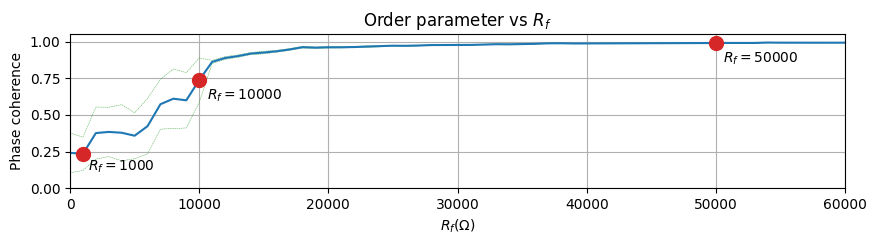

In [13]:
# import libraries
import numpy as np, scipy as sp, matplotlib.pyplot as plt, os
import quadratureNetwork as qnet #library that implement the oscillators

folderName = 'exp002'

allFiles = os.listdir(folderName)
print(allFiles)

Rf = []
pcMean = []
pcStd = []
x_max = []
# x = []
for file in allFiles:
  if file[-3:] == 'mat':
    npzfile = sp.io.loadmat(folderName+'\\'+file)
    Rf.append(npzfile['Rf'][0,0])
    pcMean.append(npzfile['pcMean'][0,0])
    pcStd.append(npzfile['pcStd'][0,0])
    x_max.append(np.max(np.abs(npzfile['x'][:,::3]))) # take the abs max of each sine signal (sin) to verify unstabillity
    # x.append(npzfile['x'][:,::3]) # take only the first signal (sin) of each oscillator

Rf = np.array(Rf)
pcMean = np.array(pcMean)
pcStd = np.array(pcStd)
sorIdx = np.argsort(Rf)
x_max = np.array(x_max)
Rf, pcMean, pcStd = Rf[sorIdx], pcMean[sorIdx], pcStd[sorIdx]


#####################################################################
#PLOTAR O GRÁFICO

plt.figure(figsize=(10,2))
plt.title(r'Order parameter vs $R_f$')
plt.xlabel(r'$R_f (\Omega)$')
plt.ylabel(r'Phase coherence')
plt.plot(Rf, pcMean+pcStd, '--', c='C02', lw=.3)
plt.plot(Rf, pcMean-pcStd, '--', c='C02', lw=.3)

Rf1 = 1000
Rf2 = 10000
Rf3 = 50000

for rf in Rf[x_max > 15]:
  plt.axvspan(rf - 1000, rf + 1000, color='yellow', alpha=.9)

# plt.plot(Rf[x_max>15])

plt.plot(Rf[Rf==Rf1], pcMean[Rf==Rf1], '.', c='C03', ms=20, zorder=10)
plt.text(Rf[Rf==Rf1]+3000, pcMean[Rf==Rf1]-.03, '$R_f=%d$'%Rf1, ha='center', va='top')

plt.plot(Rf[Rf==Rf2], pcMean[Rf==Rf2], '.', c='C03', ms=20, zorder=10)
plt.text(Rf[Rf==Rf2]+3500, pcMean[Rf==Rf2]-.05, '$R_f=%d$'%Rf2, ha='center', va='top')

plt.plot(Rf[Rf==Rf3], pcMean[Rf==Rf3], '.', c='C03', ms=20, zorder=10)
plt.text(Rf[Rf==Rf3]+3500, pcMean[Rf==Rf3]-.05, '$R_f=%d$'%Rf3, ha='center', va='top')

plt.plot(Rf, pcMean, '-', ms=15)
plt.xlim(min(Rf), max(Rf))
plt.xlim(0e3, 60e3)
plt.ylim(0.0, 1.05)
plt.grid(1, which='both');

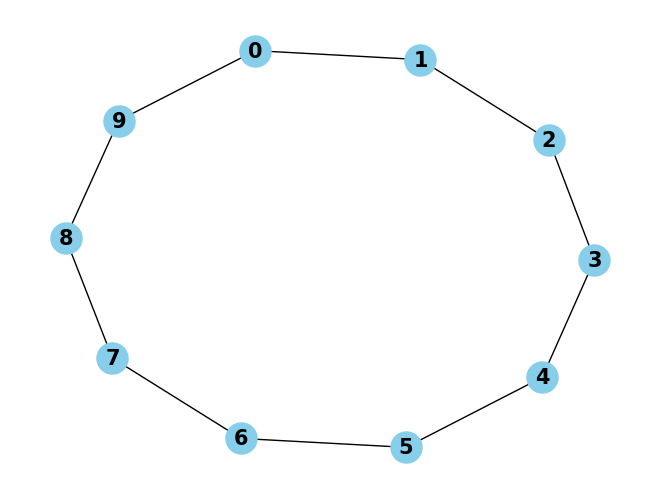

In [5]:
import networkx as nx, numpy as np, matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Define the adjacency matrix
Adj = np.array([[ 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],  # 0 <== 1, 9
                [ 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 1 <== 2, 0
                [ 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],  # 2 <== 3, 1
                [ 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],  # 3 <== 4, 2
                [ 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],  # 4 <== 5, 3
                [ 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],  # 5 <== 6, 4
                [ 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],  # 6 <== 7, 5
                [ 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],  # 7 <== 8, 6
                [ 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],  # 8 <== 9, 7
                [ 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]], # 9 <== 0, 8
                dtype=np.float64)

# Add nodes to the graph
nodes = list(range(len(Adj)))
G.add_nodes_from(nodes)


# Add edges based on the adjacency matrix
for i in range(len(Adj)):
    for j in range(len(Adj[i])):
        if Adj[i][j] == 1:
            G.add_edge(i, j)

# Draw the network
pos = nx.spring_layout(G)  # Use spring layout for better visualization
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=500, node_color='skyblue', font_size=15, edge_color='black')

# Show the plot
plt.show()